# Percolation through thick unsaturated zones with the Kinematic-Wave method

This notebook demonstrates `gwtransport.percolation`, an exact front-tracking solver for the
Kinematic-Wave (KW) percolation problem of Olsthoorn (2026, *Stromingen* 32(1)). The KW
approximation drops capillary stress from Richards' equation, leaving the scalar conservation
law

$$\frac{\partial \theta_m}{\partial t} + \frac{\partial K(\theta_m)}{\partial z} = 0,$$

solved exactly with Brooks-Corey or van Genuchten-Mualem conductivity curves, with an optional
time-only scaling of `K` (e.g. for temperature-dependent water viscosity).

**Plotting note.** The model output `q_water_table` is a *bin average* over the output time
edges, so it is drawn as **step plots**. The **exact** breakthrough — continuous, with
rarefactions from their exact self-similar profile and shocks as sharp jumps — is overlaid as a
solid line, reusing `gwtransport.fronttracking.output.identify_outlet_segments`.

**A note on the exact (`c_fixed = 0`) regime.** This solver uses a single computation path per
isotherm: every wetting shock must advance into initially-dry soil (`c = 0` on its downstream
side). All scenarios below therefore use **one wetting episode** (a rise from dry), optionally
followed by drying — which keeps every internal collision at `c_fixed = 0`. Partial drying to a
lower nonzero rate is fine (the engine resolves it through the fan-exhaustion transition; the
shock's downstream is still the dry state). Oscillating inputs, repeated wetting cycles, and
*time-varying* `k_scaling` are avoided: a varying viscosity factor `f(t)` makes the solver-frame
inlet `q_root / f` vary even at constant `q_root`, creating sub-collisions outside this regime.
The viscosity demonstration (section 4) therefore compares two runs each with a **constant**
`k_scaling`.

**Contents**

1. Soil O05 parameters
2. Step response at multiple depths (exact line + bin-averaged steps)
3. Drying-tail rarefaction breakthrough
4. Water viscosity via constant K-scaling (cold vs. warm water)

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gwtransport.fronttracking.output import concentration_at_point, identify_outlet_segments
from gwtransport.percolation import root_zone_to_water_table_kinematic_wave

warnings.filterwarnings("ignore", message="compute_bin_averaged_concentration_exact")
plt.rcParams["axes.grid"] = True

## Plot helper

`plot_breakthrough` overlays, for one percolation column:

- the **exact** outlet flux as a continuous line — constant segments drawn flat, rarefaction
  segments sampled from `RarefactionWave.concentration_at_point` (exact self-similar profile),
  shocks appearing as sharp jumps between segments;
- the **bin-averaged** `q_water_table` as a step plot (`plt.stairs`).

For a K-scaling run, the solver's exact curve is the reference-frame `K_ref`; the physical flux
is `f(t)·K_ref(t)`, so the exact line is sampled finely and multiplied by `f(t)` (a constant-
`K_ref` segment becomes time-varying once `f(t)` multiplies it). The returned `q_water_table`
is already physical.

In [2]:
def _f_at(t_days, k_scaling, tedges):
    """Piecewise-constant k_scaling f(t) sampled at t_days (days from tedges[0])."""
    if k_scaling is None:
        return np.ones_like(np.asarray(t_days, dtype=float))
    edges = ((tedges[:-1] - tedges[0]) / pd.Timedelta(days=1)).to_numpy()
    idx = np.clip(np.searchsorted(edges, t_days, side="right") - 1, 0, len(k_scaling) - 1)
    return np.asarray(k_scaling, dtype=float)[idx]


def plot_breakthrough(ax, structure, q_wt, q_wt_tedges, tedges, *, k_scaling=None, color="C0", label="", to_mm=True):
    """Overlay the exact breakthrough (line) and the bin-averaged flux (steps)."""
    state = structure["tracker_state"]
    scale = 1e3 if to_mm else 1.0  # m/day -> mm/day for display
    t_max = float((q_wt_tedges[-1] - q_wt_tedges[0]) / pd.Timedelta(days=1))

    if k_scaling is None:
        # Segment-based exact curve: sharp shocks + exact rarefactions.
        theta_lo = state.theta_at_t(0.0)
        theta_hi = state.theta_at_t(t_max)
        segments = identify_outlet_segments(theta_lo, theta_hi, state.v_outlet, state.waves, state.sorption)
        first = True
        for seg in segments:
            t0 = state.t_at_theta(seg["theta_start"])
            t1 = state.t_at_theta(seg["theta_end"])
            if seg["type"] == "constant":
                ax.plot(
                    [t0, t1],
                    [seg["concentration"] * scale] * 2,
                    color=color,
                    lw=1.6,
                    label=f"{label} exact" if first else None,
                )
            else:
                raref = seg["wave"]
                tt = np.linspace(t0, t1, 80)
                cc = np.array([
                    raref.concentration_at_point(state.v_outlet, state.theta_at_t(float(t))) or 0.0 for t in tt
                ])
                ax.plot(tt, cc * scale, color=color, lw=1.6, label=f"{label} exact" if first else None)
            first = False
    else:
        # K-scaling: fine-sample K_ref and multiply by f(t).
        tt = np.linspace(0.0, t_max, 1500)
        kref = np.array([
            concentration_at_point(state.v_outlet, state.theta_at_t(float(t)), state.waves, state.sorption) for t in tt
        ])
        ax.plot(tt, kref * _f_at(tt, k_scaling, tedges) * scale, color=color, lw=1.6, label=f"{label} exact")

    edges = ((q_wt_tedges - q_wt_tedges[0]) / pd.Timedelta(days=1)).to_numpy()
    ax.stairs(q_wt * scale, edges, color=color, ls="--", lw=1.2, alpha=0.8, label=f"{label} bin avg")

## 1. Soil O05 (coarse sand)

`K_s = 17.4 cm/d`, `θ_r = 0.01`, `θ_s = 0.337`. Brooks-Corey `λ = 0.25` (a = 11); van
Genuchten `n = 2.28`, `L = 0.5` (Heinen et al. 2020 Staringreeks).

In [3]:
THETA_R, THETA_S, K_S = 0.01, 0.337, 0.174  # m/day
BC_LAMBDA, VG_N = 0.25, 2.28

## 2. Step response at multiple depths

Constant root-zone flux `q = 2 mm/d` switched on at `t = 0` over initially-dry soil. The exact
breakthrough is a single sharp wetting-front jump at arrival (one shock, no collisions); the
bin-averaged output (10-day bins) ramps across the bin that contains the arrival, so the step
crossing the exact jump takes the bin's flow-weighted mean. Deeper columns arrive later because
the front travels at constant speed in depth.

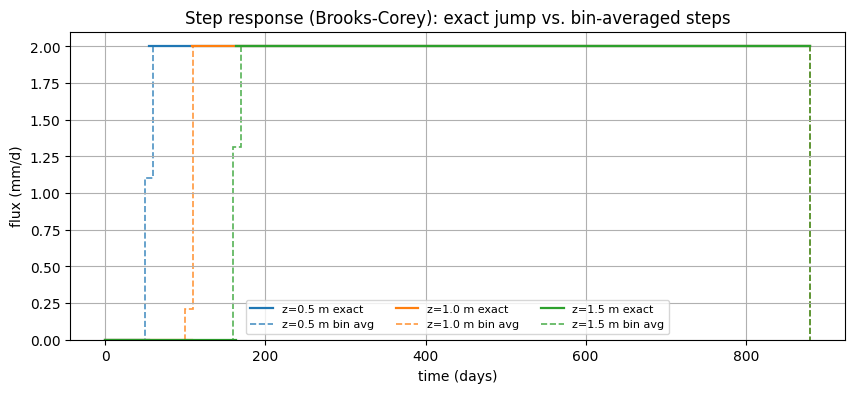

In [4]:
tedges = pd.date_range("2000-01-01", "2002-06-01", freq="D")
n = len(tedges) - 1
q0 = 0.002
q_root = np.full(n, q0)
out_tedges = pd.date_range("2000-01-01", "2002-06-01", freq="10D")  # coarse -> visible steps

fig, ax = plt.subplots(figsize=(10, 4))
for j, z in enumerate([0.5, 1.0, 1.5]):
    q_wt, structures = root_zone_to_water_table_kinematic_wave(
        q_root_zone=q_root,
        tedges=tedges,
        q_water_table_tedges=out_tedges,
        cumulative_pore_volumes_outlet=np.array([THETA_S * z]),
        theta_r=THETA_R,
        theta_s=THETA_S,
        k_s=K_S,
        brooks_corey_lambda=BC_LAMBDA,
    )
    plot_breakthrough(ax, structures[0], q_wt, out_tedges, tedges, color=f"C{j}", label=f"z={z} m")
ax.set_xlabel("time (days)")
ax.set_ylabel("flux (mm/d)")
ax.set_title("Step response (Brooks-Corey): exact jump vs. bin-averaged steps")
ax.legend(ncol=3, fontsize=8)
plt.show()

## 3. Drying-tail rarefaction breakthrough

A single wetting episode (`q = 3 mm/d` for 120 days, long enough for the front to fully reach
`z = 1 m`) followed by drying to a lower rate (`q = 0.5 mm/d`). The outlet first sees the sharp
wetting front, holds the wet plateau, then a smooth **rarefaction** fan as the drying tail
arrives, finally settling at the new dry rate. Because the column was never re-wetted, the
shock's downstream stays at the dry `c = 0` state throughout: the run resolves with just three
events (one shock, one rarefaction) and no `max_iterations` blow-up.

The exact line renders the self-similar fan; the weekly bin-averaged steps straddle and cross
it, each step being the bin's flow-weighted mean of the exact curve.

events=3, shocks=1, rarefactions=1


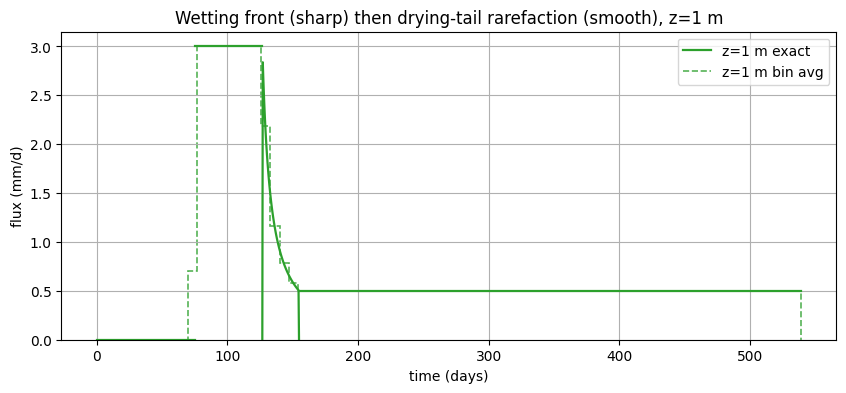

In [5]:
tedges2 = pd.date_range("2000-01-01", periods=541, freq="D")  # ~18 months
n2 = len(tedges2) - 1
q_root2 = np.full(n2, 0.0005)
q_root2[:120] = 0.003  # 120-day wetting episode, then drying tail
out_tedges2 = pd.date_range(tedges2[0], tedges2[-1], freq="7D")

q_wt2, structures2 = root_zone_to_water_table_kinematic_wave(
    q_root_zone=q_root2,
    tedges=tedges2,
    q_water_table_tedges=out_tedges2,
    cumulative_pore_volumes_outlet=np.array([THETA_S * 1.0]),
    theta_r=THETA_R,
    theta_s=THETA_S,
    k_s=K_S,
    brooks_corey_lambda=BC_LAMBDA,
)
print(
    f"events={structures2[0]['n_events']}, shocks={structures2[0]['n_shocks']}, "
    f"rarefactions={structures2[0]['n_rarefactions']}"
)

fig, ax = plt.subplots(figsize=(10, 4))
plot_breakthrough(ax, structures2[0], q_wt2, out_tedges2, tedges2, color="C2", label="z=1 m")
ax.set_xlabel("time (days)")
ax.set_ylabel("flux (mm/d)")
ax.set_title("Wetting front (sharp) then drying-tail rarefaction (smooth), z=1 m")
ax.legend()
plt.show()

## 4. Water viscosity via constant K-scaling (cold vs. warm water)

Hydraulic conductivity scales inversely with dynamic viscosity, `K ∝ 1/μ(T)`, so the
`k_scaling` argument carries the dimensionless factor `f = μ_ref/μ(T)`. Water viscosity drops
from `μ ≈ 1.52 mPa·s` at 5 °C to `≈ 0.89 mPa·s` at 25 °C; with `μ_ref = μ(10 °C) = 1.31 mPa·s`
this gives `f ≈ 0.86` for cold water and `f ≈ 1.47` for warm water — a 1.7× swing in effective
`K_s`.

A *time-varying* `f(t)` would push the solver out of the exact `c_fixed = 0` regime (it makes
the solver-frame inlet `q_root/f` vary even at constant `q_root`). So instead we compare two
separate runs, **each with a constant seasonal `f`** — representative of a cold-season vs. a
warm-season column. To isolate the conductivity effect we hold the soil-moisture forcing fixed
between runs (equivalently, a fixed solver-frame inlet `q_root/f`), so the physical input flux
scales with `f`: warmer water transmits proportionally more flux through the same wetness and
drains faster, producing an **earlier, sharper breakthrough** and a higher plateau. The exact
line is `f·K_ref(t)`; the returned `q_water_table` is already physical.

cold (5 °C): f=0.862, events=3, shocks=1, rarefactions=1
warm (25 °C): f=1.472, events=3, shocks=1, rarefactions=1


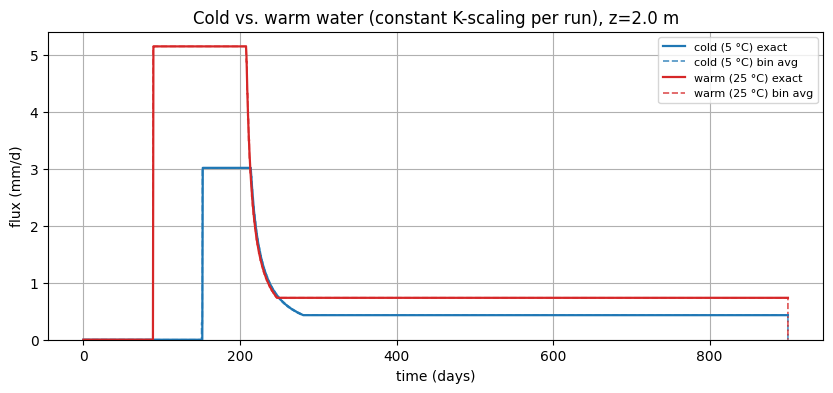

In [6]:
tedges3 = pd.date_range("2000-01-01", periods=901, freq="D")  # ~2.5 years, daily
n3 = len(tedges3) - 1
z3 = 2.0  # deeper column makes the viscosity-driven travel-time difference clearly visible

mu_ref = 1.31  # mPa·s, reference at 10 °C
f_cold = mu_ref / 1.519  # 5 °C  -> f < 1 (more viscous, slower)
f_warm = mu_ref / 0.890  # 25 °C -> f > 1 (less viscous, faster)

# Same soil-moisture forcing per run: q_root_zone = q_base * f keeps the solver-frame inlet
# q_root/f identical, isolating the conductivity (viscosity) effect.
q_base = np.full(n3, 0.0005)
q_base[:200] = 0.0035  # single 200-day wetting episode, then drying tail

fig, ax = plt.subplots(figsize=(10, 4))
for f_val, name, c in [(f_cold, "cold (5 °C)", "C0"), (f_warm, "warm (25 °C)", "C3")]:
    k_scaling = np.full(n3, f_val)
    q_root3 = q_base * f_val
    q_wt3, struct3 = root_zone_to_water_table_kinematic_wave(
        q_root_zone=q_root3,
        tedges=tedges3,
        q_water_table_tedges=tedges3,
        cumulative_pore_volumes_outlet=np.array([THETA_S * z3]),
        theta_r=THETA_R,
        theta_s=THETA_S,
        k_s=K_S,
        brooks_corey_lambda=BC_LAMBDA,
        k_scaling=k_scaling,
    )
    print(
        f"{name}: f={f_val:.3f}, events={struct3[0]['n_events']}, "
        f"shocks={struct3[0]['n_shocks']}, rarefactions={struct3[0]['n_rarefactions']}"
    )
    plot_breakthrough(ax, struct3[0], q_wt3, tedges3, tedges3, k_scaling=k_scaling, color=c, label=name)
ax.set_xlabel("time (days)")
ax.set_ylabel("flux (mm/d)")
ax.set_title(f"Cold vs. warm water (constant K-scaling per run), z={z3} m")
ax.legend(fontsize=8)
plt.show()

## References

- Olsthoorn, T.N. (2026). Percolation through thick unsaturated zones — Munsflow vs. the Kinematic Wave. *Stromingen* 32(1).
- Heinen, M., Bakker, G., Wösten, J.M.H. (2020). *Waterretentie en Doorlatendheidskarakteristieken … Staringreeks. Update 2018.* Wageningen Environmental Research, Report 2978.
- Charbeneau, R.J. (2000). *Groundwater Hydraulics and Pollutant Transport.* Prentice Hall.